# This is a script used to plot the temp change as strips


In [15]:
import xarray as xr
import numpy as np
import pandas as pd

In [16]:

variables = ["temp","precip","evap","soiltemp","sm","snowdepth","LAI_PFT","windspeed","iceconc","ice_sheet"]
units = ["degC", "mm month^-1", "mm month^-1", "degC", "kg m^-1", "mm", "leaf area index LAI", "m s^-1", "%"," "]  # Units for each variable
longnames = [
    "2m Air Temperature",
    "Surface Precipitation",
    "Evapotranspiration",
    "Soil Temperature from top layer",
    "Soil Moisture from top layer",
    "Snow Depth",
    "Leaf Area Index (LAI)",
    "10m Wind Speed",
    "Sea Ice Concentration",
    "Ice Sheet 0/1"
]  # Long names for each variable
scenarios = ["natural","SSP126","SSP245","SSP370","SSP585","10000PGC"]  # or "historical"

site = "_LA"
downscaled = False  # Set to True if downscaled data is used, False otherwise
var = 9


# now read in the data

In [ ]:
data_path = "site_data/lowres_results/"

def load_data_for_scenario(scen):
    if downscaled:
        data_file = f"downscaled/{variables[var]}_{scenarios[scen]}_site{site}_downscaled.txt"
    else:
        data_file = f'{variables[var]}_{scenarios[scen]}_site{site}.txt'
    
    print("Loading data from:", data_file)
    data = np.loadtxt(data_path + data_file)
    print(f"shape of data for {scenarios[scen]}:", data.shape)
    return data


In [18]:
# print data info for all scenarios, min, max, mean, std
for scen_idx in range(len(scenarios)):
    data = load_data_for_scenario(scen_idx)
    print(f"Data stats for {scenarios[scen_idx]} - min: {data.min()}, max: {data.max()}, mean: {data.mean()}, std: {data.std()}")

Loading data from: site_LA/ice_sheet_natural_site_LA.txt
shape of data for natural: (90, 1001)
Data stats for natural - min: -0.517741, max: 1.000105, mean: 0.1036232962037962, std: 0.07602013400069361
Loading data from: site_LA/ice_sheet_SSP126_site_LA.txt
shape of data for SSP126: (90, 1001)
Data stats for SSP126 - min: -0.517741, max: 1.000105, mean: 0.10376427163947163, std: 0.07449906277537796
Loading data from: site_LA/ice_sheet_SSP245_site_LA.txt
shape of data for SSP245: (90, 1001)
Data stats for SSP245 - min: -0.517741, max: 1.000105, mean: 0.10569975834165836, std: 0.07094285665317777
Loading data from: site_LA/ice_sheet_SSP370_site_LA.txt
shape of data for SSP370: (90, 1001)
Data stats for SSP370 - min: -0.517741, max: 1.000105, mean: 0.10669431672771675, std: 0.06595938379791262
Loading data from: site_LA/ice_sheet_SSP585_site_LA.txt
shape of data for SSP585: (90, 1001)
Data stats for SSP585 - min: -0.517741, max: 1.000105, mean: 0.10795713300033302, std: 0.0607066981398387

# Start data process


In [19]:
def process_data(data):
    # Calculate the number of members with values over -1 and below -5 for each time step
    warm_mem = np.sum(data < 1.0, axis=0) # presence of ice sheet should be 0 or 1, make threshold at 0.5
    cold_mem = np.sum(data >= 1.0, axis=0)

    # Check if the sum of warm_mem, cold_mem equals total members for each time step
    total_mem = warm_mem + cold_mem
    if not np.all(total_mem == data.shape[0]):
        raise ValueError(f"Error: The sum of warm_mem and cold_mem is not {data.shape[0]} for all time steps.")
    
    return warm_mem, cold_mem

# Load and process data for all scenarios
all_data = {}
all_processed = {}
for scen_idx in range(len(scenarios)):
    all_data[scen_idx] = load_data_for_scenario(scen_idx)
    all_processed[scen_idx] = process_data(all_data[scen_idx])


Loading data from: site_LA/ice_sheet_natural_site_LA.txt
shape of data for natural: (90, 1001)
Loading data from: site_LA/ice_sheet_SSP126_site_LA.txt
shape of data for SSP126: (90, 1001)
Loading data from: site_LA/ice_sheet_SSP245_site_LA.txt
shape of data for SSP245: (90, 1001)
Loading data from: site_LA/ice_sheet_SSP370_site_LA.txt
shape of data for SSP370: (90, 1001)
Loading data from: site_LA/ice_sheet_SSP585_site_LA.txt
shape of data for SSP585: (90, 1001)
Loading data from: site_LA/ice_sheet_10000PGC_site_LA.txt
shape of data for 10000PGC: (90, 1001)


In [20]:
# check the data
for scen_idx in range(len(scenarios)):
    warm_mem, cold_mem = all_processed[scen_idx]
    print(f"sum of cold members and warm members for {scenarios[scen_idx]}: cold={cold_mem.sum()}, warm={warm_mem.sum()}")

sum of cold members and warm members for natural: cold=6, warm=90084
sum of cold members and warm members for SSP126: cold=4, warm=90086
sum of cold members and warm members for SSP245: cold=6, warm=90084
sum of cold members and warm members for SSP370: cold=9, warm=90081
sum of cold members and warm members for SSP585: cold=6, warm=90084
sum of cold members and warm members for 10000PGC: cold=2, warm=90088


# Start to plot

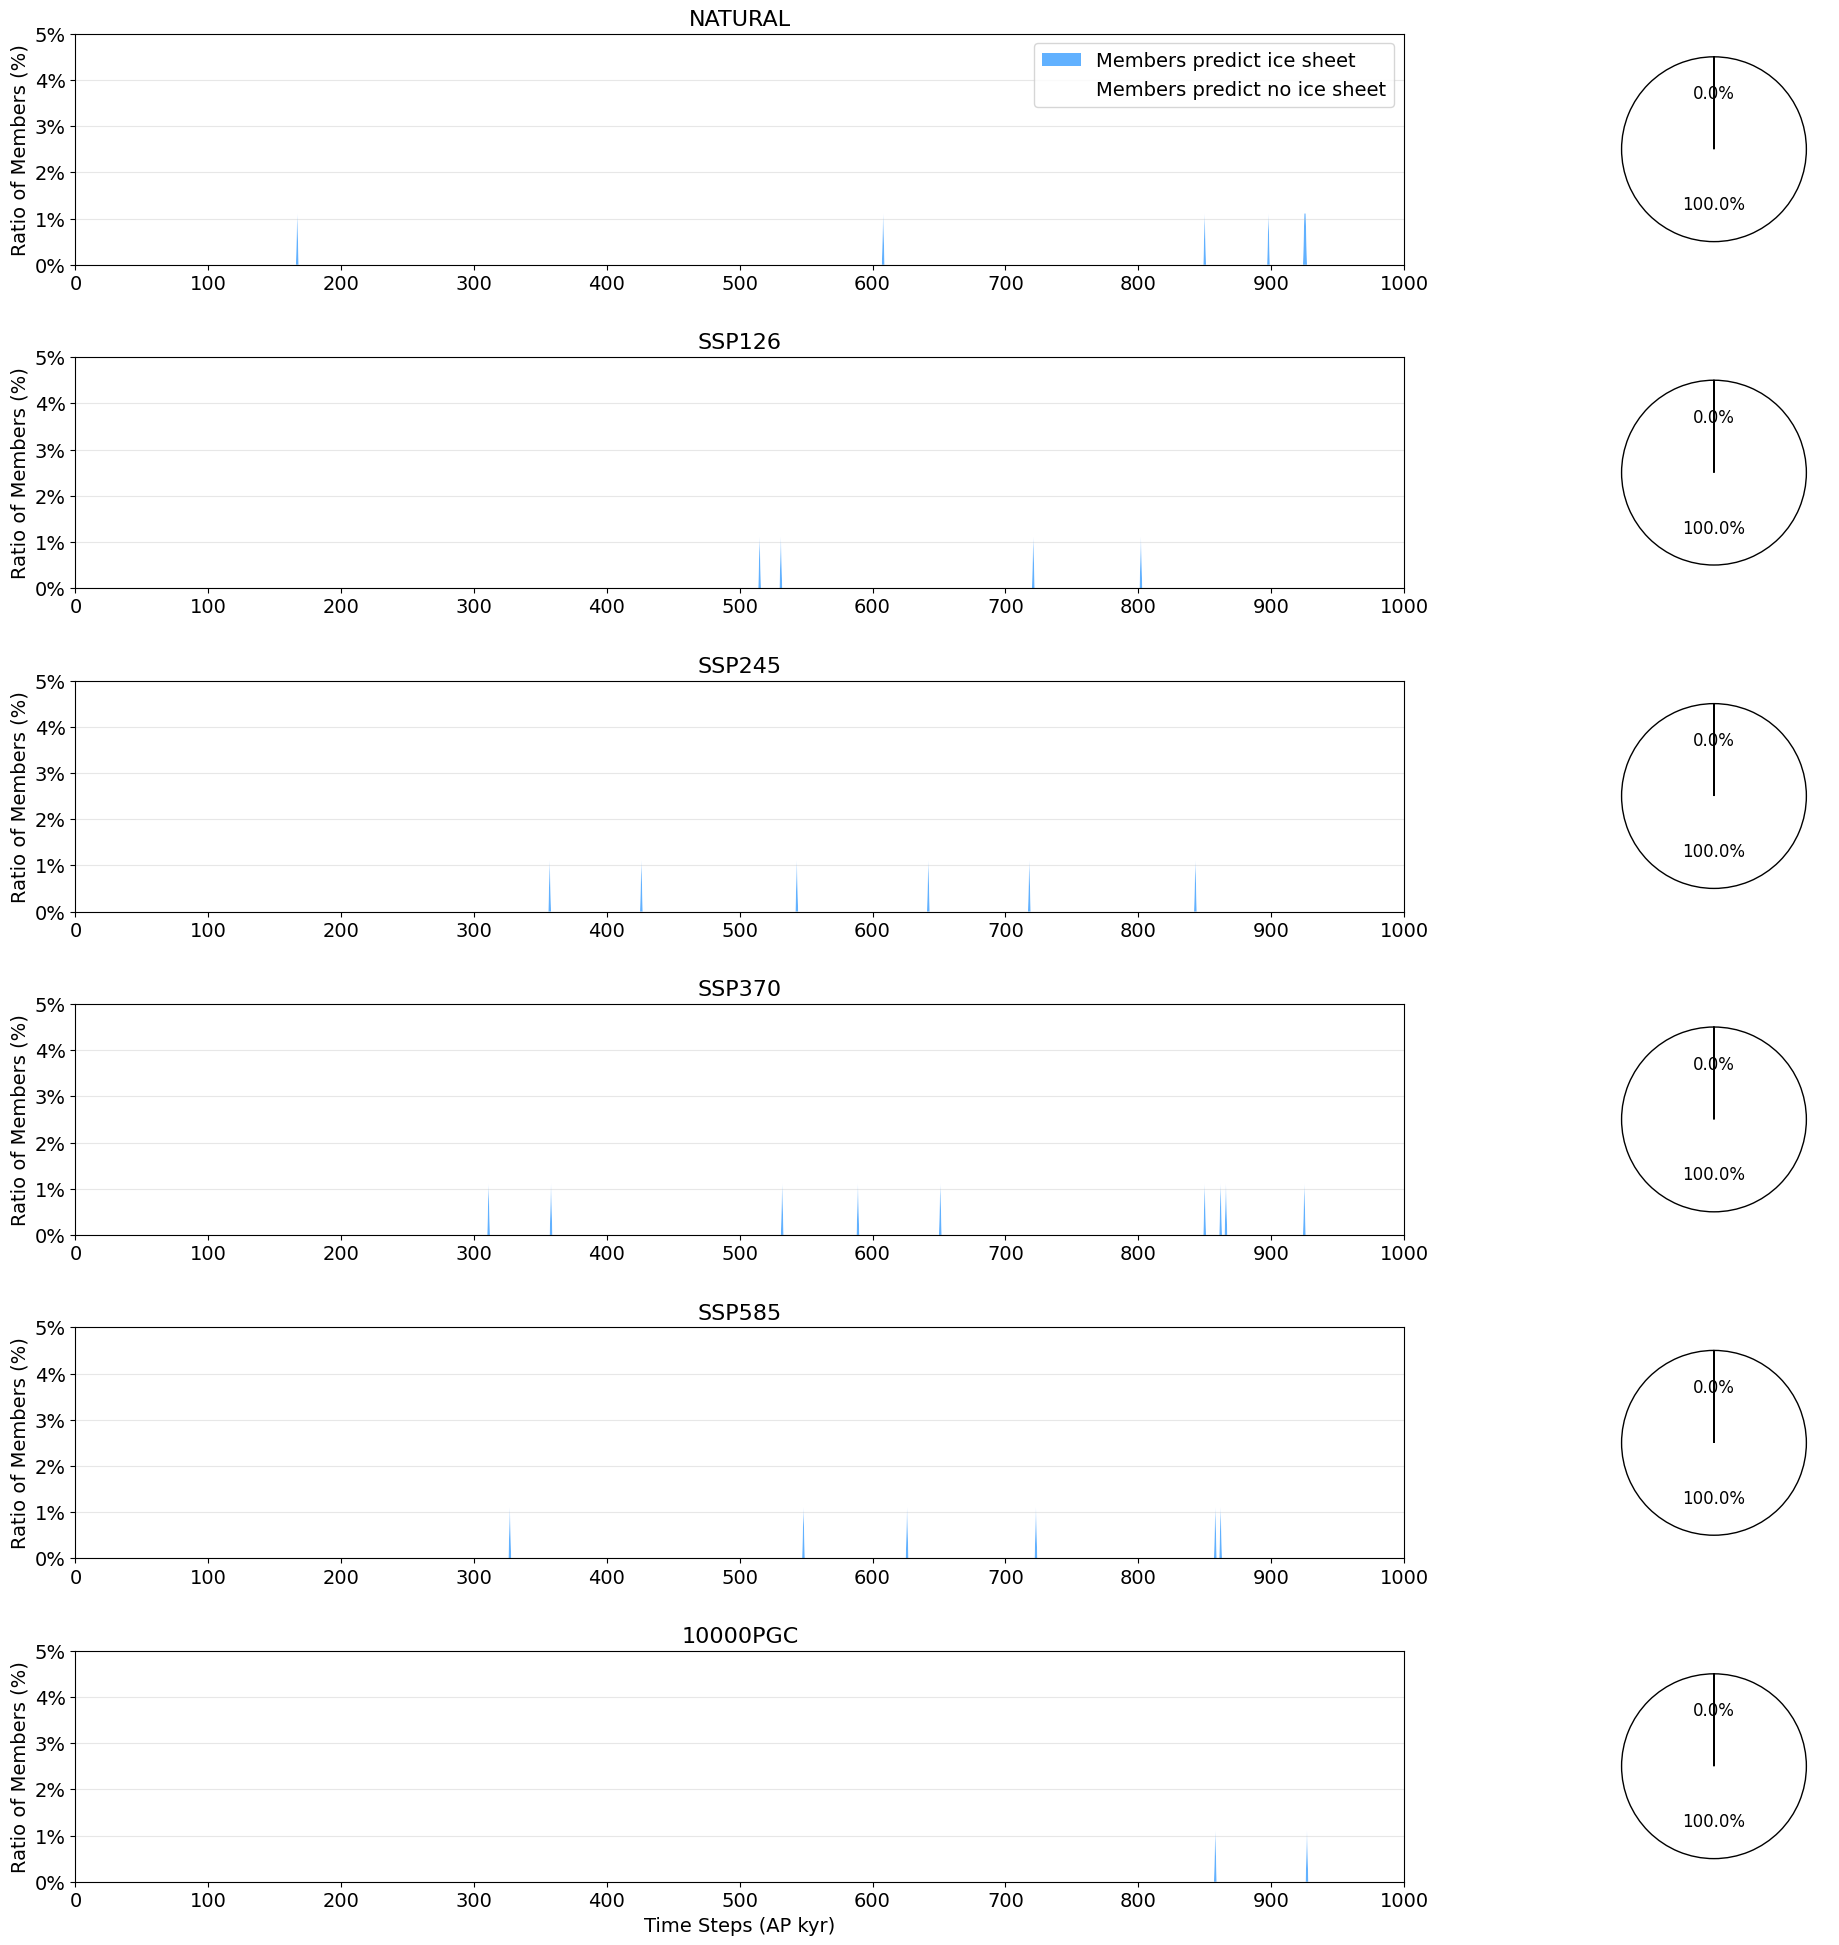

In [21]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create time steps array
time_steps = np.arange(all_data[0].shape[1])

# Create a figure with subplots: 2 columns per scenario (stacked area + pie chart)
n_scen = len(scenarios)
fig = plt.figure(figsize=(24, 4 * n_scen))
gs = GridSpec(n_scen, 2, figure=fig, width_ratios=[3, 1], hspace=0.4, wspace=0.1)

for scen_idx, scenario in enumerate(scenarios):
    warm_mem, cold_mem = all_processed[scen_idx]
    total_mem = warm_mem + cold_mem
    warm_ratio = warm_mem / total_mem
    cold_ratio = cold_mem / total_mem
    warm_percent = warm_ratio * 100
    cold_percent = cold_ratio * 100
    
    # Left subplot: stacked area plot
    ax1 = fig.add_subplot(gs[scen_idx, 0])
    ax1.stackplot(time_steps, cold_percent, warm_percent, colors=['dodgerblue', 'white'], alpha=0.7)
    
    # Add legend only for the first scenario
    if scen_idx == 0:
        ax1.legend(
            ['Members predict ice sheet', 'Members predict no ice sheet'],
            loc='upper right', fontsize=25
        )
    
    ax1.set_xlim(0, 1000)
    ax1.set_xticks(time_steps[::100])
    ax1.set_xticklabels(time_steps[::100], fontsize=16)
    ax1.tick_params(axis='y', labelsize=16)
    ax1.set_ylabel('Ratio of Members (%)', fontsize=25)
    ax1.set_ylim(0, 5)
    ax1.set_yticks(np.arange(0, 6, 1))
    ax1.set_yticklabels([f'{v}%' for v in np.arange(0, 6, 1)], fontsize=16)
    ax1.set_title(f'{scenario.upper()}', fontsize=25)
    ax1.grid(axis='y', alpha=0.3)
    if scen_idx == n_scen - 1:
        ax1.set_xlabel('Time Steps (AP kyr)', fontsize=20)
    
    # Right subplot: pie chart
    ax2 = fig.add_subplot(gs[scen_idx, 1])
    total_cold = np.sum(cold_mem)
    total_warm = np.sum(warm_mem)
    ax2.pie(
        [total_cold, total_warm], 
        colors=['dodgerblue', 'white'], 
        autopct='%1.1f%%', 
        startangle=90,
        textprops={'fontsize': 12}, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )

plt.savefig(f"plots/{variables[var]}_site{site}_stackplot_with_pie.png", dpi=300, bbox_inches='tight')
plt.show()
